In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt 
from data_processing.processing.figure_of_merit import fit_fom, FOM, gaussian, n_sigma_classifier,  bimodal
from data_processing.reporting.plotting import plot_fom, plot_scatter, plot_classification_with_grouping
from scipy.optimize import curve_fit

In [2]:
# Set up experiment
def fit_gauss(counts, bins):
    params, cov = curve_fit(gaussian, bins[:-1], counts)
    return abs(params), cov

EXP_NAME = "echem_exp"
ROOT = Path("../sample_datasets/.temp_echem/")
AMPLITUDES_PATH = ROOT / "amplitudes.csv"
PSD_PATH =  ROOT / "psd.csv"

psd = pd.read_csv(PSD_PATH, header=None)
amplitudes = pd.read_csv(AMPLITUDES_PATH, header=None)
psd_report = pd.concat([psd, amplitudes], axis=1)
psd_report.columns = ["tail / total", "amplitude"]

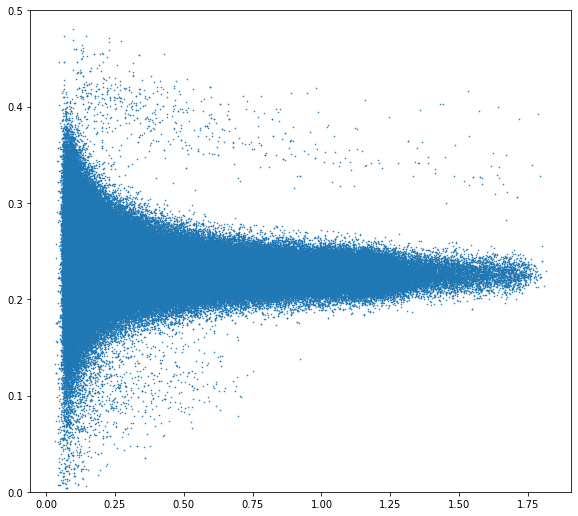

In [3]:
# Plot PSD
fig, ax = plot_scatter(psd_report["amplitude"], psd_report["tail / total"])
ax.set_ylim(0,0.5)
fig.set_figheight(7)
fig.set_figwidth(8)

# Converting Voltage to Light Output

In [4]:
V1 = 205 * 1e-3
L1 = 900 * 1e-3
V2 = 290 * 1e-3
L2 = 1200 * 1e-3

m = (L2-L1) / (V2-V1)
b =  L1 - m * V1

def v_to_l(voltage):
    return m * voltage + b

psd_report["energy"] = psd_report["amplitude"].apply(v_to_l)

(0.0, 0.5)

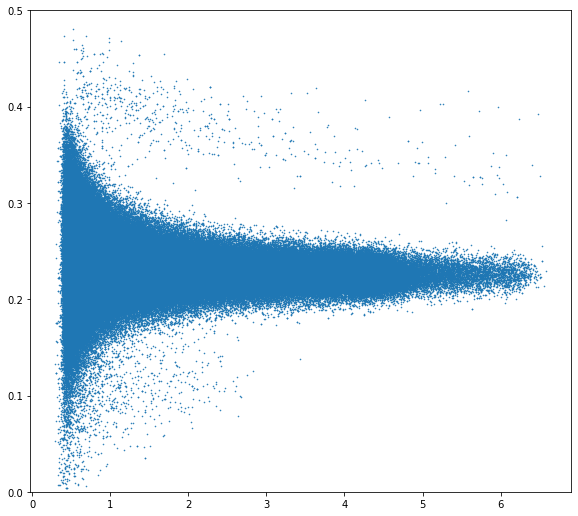

In [5]:
fig, ax = plot_scatter(psd_report["energy"], psd_report["tail / total"])
fig.set_figheight(7)
fig.set_figwidth(8)
ax.set_ylim(0,0.5)

(0.0, 0.45)

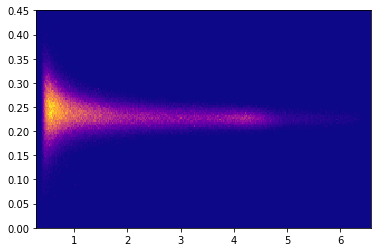

In [6]:
x, y = psd_report["energy"], psd_report["tail / total"]
Z, xe, ye = np.histogram2d(x, y, 300)

cmap = plt.colormaps["plasma"]
plt.pcolormesh(xe, ye, Z.T, cmap=cmap)
plt.ylim(0,0.45)

In [9]:
i = 4
zeta = Z.T
xe[i], zeta[:,i]

(0.3721352470588234,
 array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  2.,  1.,  0.,  0.,
         0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  2.,  1.,  2.,  0.,  1.,
         0.,  0.,  1.,  0.,  0

(0.0, 0.5)

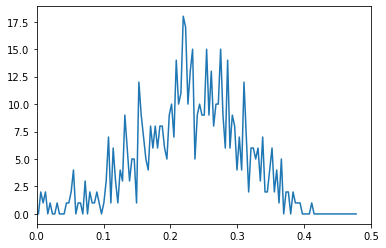

In [71]:
plt.plot(ye[:-1], zeta[:,i])
# plt.ylim(0,)
plt.xlim(0,0.5)

(0.0, 0.5)

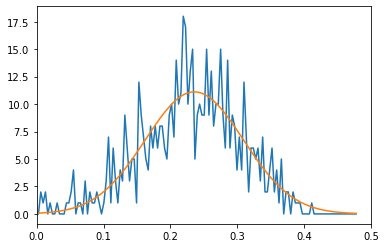

In [72]:
params, _ = curve_fit(
    gaussian,
    ye[:-1], 
    zeta[:,i],
#     bounds=((0.20,0.001,1),(0.3,0.1,250))
)

plt.plot(ye[:-1], zeta[:,i])
plt.plot(ye[:-1], gaussian(ye[:-1], *params))
plt.xlim(0,0.5)
# plt.yscale("log")

In [86]:
def sigma_slice(ye, counts, idx):
    return curve_fit(
        gaussian,
        ye[:-1], 
        counts[:,idx],
        bounds=((0.20,0.001,1),(0.3,0.1,250))
    )


def get_gamma_bound_point(xe, ye, counts, idx):
    energy = (xe[idx] + xe[idx + 1]) / 2
    (mu, sigma, A), cov = sigma_slice(ye, counts, idx)
    
    return energy, mu, sigma
    


energy = []
sigma = []
mu = []
lower_bound = []
upper_bound = []

for idx in range(3, len(xe) - 1):
    e, m, s = get_gamma_bound_point(xe, ye, zeta, idx)
    energy.append(e)
    sigma.append(s)
    mu.append(m)

In [87]:
from scipy.signal import savgol_filter

f_sigma = savgol_filter(sigma, 21, 7)
f_mu = savgol_filter(mu, 17, 3)

for s, m in zip(f_sigma, f_mu):
    lower_bound.append(m + 4*s)
    upper_bound.append(m + 16*s)

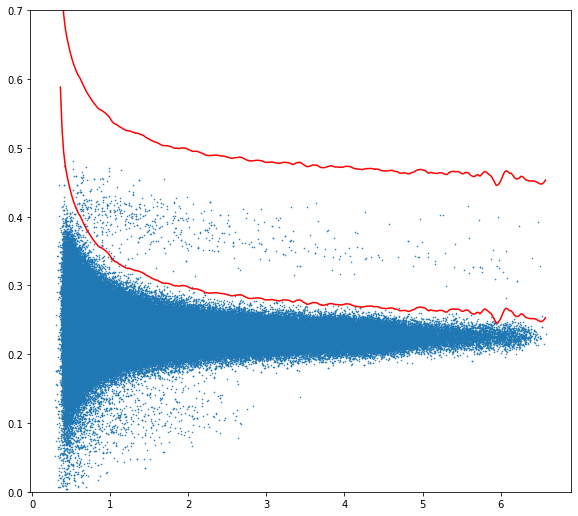

In [88]:
fig, ax = plot_scatter(psd_report["energy"], psd_report["tail / total"])
fig.set_figheight(7)
fig.set_figwidth(8)
ax.set_ylim(0,0.7)

ax.plot(energy, lower_bound, 'r-')
ax.plot(energy, np.array(lower_bound) + 0.2, 'r-')

# Bounding Box

Find the bounding box with `n` sigma tolerance. Change `n` if necessary.



In [ ]:
def lo_output(Ep):
    return 0.748*Ep-2.41*(1-np.exp(-0.298*Ep))

L1, L2, L3 = lo_output(np.array([2.5, 4.0, 6.0]))

L1, L2, L3

In [ ]:
t = 2704.29

def get_bounded_counts(psd, Ll, Lr):
    return psd[psd["energy"].between(Ll, Lr)].shape[0]

r1 = get_bounded_counts(neutrons, L1, L2) / t
r2 = get_bounded_counts(neutrons, L2, L3) / t
r3 = get_bounded_counts(neutrons, L3, A) / t

rates = [r1, r2, r3]

rates

In [ ]:
s1, s2, s3 = np.sqrt(np.array([r1, r2, r3]) * t) / t

sigmas = [s1, s2, s3]

sigmas

In [ ]:
bins = ["2.5 $MeV$", "4.5 $MeV$", "Control"]

fig, ax = plt.subplots(figsize=(8,8))
ax.errorbar(bins, rates, yerr=sigmas, marker = "o", linestyle="")
ax.set_ylabel("s")
ax.set_xlabel(" ROI")
plt.show()

# FOM

Here we fit the two histograms to Gaussian distributions and calculate the FOM.

In [ ]:
n_bins = 100
gammas = psd_report.copy()
gammas = gammas.drop(neutrons.index)
gamma_counts, gamma_bins = np.histogram(gammas["tail / total"], n_bins)
plt.plot(gamma_bins[:-1], gamma_counts)

gamma_params, _ = curve_fit(
    gaussian,
    gamma_bins[:-1], 
    gamma_counts,
    bounds=((0.20,0.001,1),(0.3,0.1,10e5))
)
plt.plot(gamma_bins[:-1], gaussian(gamma_bins[:-1], *gamma_params))
plt.show()

In [ ]:
neutron_counts, neutron_bins = np.histogram(neutrons["tail / total"], n_bins)
plt.plot(neutron_bins[:-1], neutron_counts)

neutron_params, _ = fit_gauss(neutron_counts, neutron_bins)
plt.plot(neutron_bins[:-1], gaussian(neutron_bins[:-1], *neutron_params))
plt.show()

In [ ]:
psd_range = np.linspace(0,0.5,200)

plt.plot(
    psd_range, gaussian(psd_range, *gamma_params), label="$\gamma$"
)

plt.plot(
    psd_range, gaussian(psd_range, *neutron_params), label="Neutrons"
)

plt.legend()
plt.yscale("log")
plt.xlim(0.1,0.5)
plt.ylim(1, gamma_params[-1] + 1e4)
plt.title(f"FOM = {FOM(*neutron_params[:-1], *gamma_params[:-1]):.3f} @ $V_{{cutoff}}$={cutoff_voltage}")
plt.show()